# Exploración CLR y PCA: taxonomía y funciones

La preparación es distinta para géneros MetaPhlAn y rutas funcionales HUMAnN,
pero ambas usan el mismo análisis modular: limpiar muestras, amalgamar rasgos
raros en `Other`, aplicar CLR, ajustar PCA, crear el biplot y exportar salidas.

En cada sección, cambia `ARROW_LABELS` según lo que quieras mostrar en las
flechas: `"names"`, `"numbers"` o `"none"`. Cuando se usan números, se guarda
una tabla de referencias en `results/tables/02_clr_pca_exploration/`.


El preprocesamiento reproduce los parámetros del notebook original: umbral absoluto de 180 ceros, suma composicional 100/1 y pseudoconteo `min_value / 2` con corrección de masa.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

DATA_ROOT = PROJECT_ROOT / "data"
DATASETS = DATA_ROOT / "processed"
EXTERNAL_DATA = DATA_ROOT / "external"
FIGURES = PROJECT_ROOT / "results" / "figures" / "02_clr_pca_exploration"
TABLES = PROJECT_ROOT / "results" / "tables" / "02_clr_pca_exploration"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

METADATA = pd.read_csv(DATASETS / "latinbiota_sample_metadata.csv")
OUTLIERS = [
    "37082_3#16", "37082_2#4", "37035_2#22",
    "37035_7#18", "36703_3#20", "36703_3#4",
]


## Funciones comunes


In [2]:
def remove_outlier_samples(abundance, outliers):
    # Elimina exclusivamente las muestras listadas como atípicas.
    return abundance.drop(index=outliers, errors="ignore").copy()


def keep_samples_with_lifestyle(abundance, metadata):
    # Alinea abundancias y conserva únicamente Rural/Urban.
    lifestyle = metadata.set_index("Lane")["Lifestyle"].reindex(abundance.index)
    valid = lifestyle.isin(["Rural", "Urban"])
    return abundance.loc[valid].copy(), lifestyle.loc[valid].copy()


def amalgamate_sparse_features(abundance, zero_threshold=180,
                               composition_total=100.0, other_name="otros"):
    # Reproduce el original: amalgama columnas con más de zero_threshold ceros.
    zero_counts = (abundance == 0).sum(axis=0)
    sparse_columns = abundance.columns[zero_counts > zero_threshold]

    result = abundance.copy()
    result[other_name] = result.loc[:, sparse_columns].sum(axis=1)
    result = result.drop(columns=sparse_columns)

    # Completa la masa no clasificada para que cada fila sume 100 (taxonomía) o 1 (funciones).
    missing_mass = composition_total - result.sum(axis=1)
    result[other_name] = result[other_name] + missing_mass
    return result


def replace_zeros_preserving_total(abundance, pseudocount):
    # Reproduce la corrección original: reemplaza ceros y reparte el exceso entre columnas.
    result = abundance.copy()
    zero_count_per_sample = (result == 0).sum(axis=1)
    result = result.replace(0, pseudocount)
    correction = (zero_count_per_sample * pseudocount) / result.shape[1]
    return result.sub(correction, axis=0)


def apply_clr(abundance):
    # CLR exacto del original; los ceros ya fueron reemplazados previamente.
    if (abundance <= 0).any().any():
        raise ValueError("CLR requiere valores positivos después de corregir los ceros.")
    log_abundance = np.log(abundance)
    return log_abundance.sub(log_abundance.mean(axis=1), axis=0)


def fit_pca(clr_data):
    # Ajusta PCA y calcula la contribución como |PC1| + |PC2|, igual que el original.
    pca = PCA(n_components=2)
    scores = pd.DataFrame(pca.fit_transform(clr_data), index=clr_data.index, columns=["PC1", "PC2"])
    loadings = pd.DataFrame(pca.components_.T, index=clr_data.columns, columns=["PC1", "PC2"])
    loadings["contribution"] = loadings[["PC1", "PC2"]].abs().sum(axis=1)
    return pca, scores, loadings.sort_values("contribution", ascending=False)


def select_distinct_directions(loadings, top_candidates=30, distance_threshold=0.1):
    # Agrupa las cargas principales por dirección coseno y elige un representante por grupo.
    candidates = loadings.head(min(top_candidates, len(loadings))).copy()
    if len(candidates) < 2:
        groups = np.ones(len(candidates), dtype=int)
    else:
        distances = pdist(candidates[["PC1", "PC2"]].to_numpy(), metric="cosine")
        groups = fcluster(linkage(distances, method="average"), distance_threshold, criterion="distance")

    directions = []
    for group_id in np.unique(groups):
        members = candidates.iloc[np.where(groups == group_id)[0]]
        representative = members["contribution"].idxmax()
        feature_names = list(members.index)
        feature_names.sort(key=lambda name: (str(name).startswith("GGB"), -members.loc[name, "contribution"]))
        directions.append({
            "representative": representative,
            "features": feature_names,
            "PC1": loadings.loc[representative, "PC1"],
            "PC2": loadings.loc[representative, "PC2"],
            "contribution": loadings.loc[representative, "contribution"],
        })
    return pd.DataFrame(directions).sort_values("contribution", ascending=False).reset_index(drop=True)


def format_direction_name(features, max_names=3):
    # Resume los nombres asociados a una dirección para evitar etiquetas demasiado largas.
    if len(features) <= max_names:
        return "\n".join(features)
    return "\n".join(features[:max_names]) + f"\n(+{len(features) - max_names} más)"


def plot_pca_biplot(scores, lifestyle, directions, pca, title,
                    arrow_labels="names", arrow_scale=100, figure_size=(8, 8), dpi=300):
    # Reproduce el estilo de los biplots originales.
    if arrow_labels not in {"names", "numbers", "none"}:
        raise ValueError("arrow_labels debe ser 'names', 'numbers' o 'none'.")

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "font.size": 10,
        "axes.linewidth": 1.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
    })
    fig, ax = plt.subplots(figsize=figure_size, dpi=dpi)
    colors = plt.cm.Set2.colors
    label_translation = {"Rural": "Rural", "Urban": "Urbano"}

    ax.grid(True, alpha=0.2, linestyle="--", linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5, zorder=1)
    ax.axvline(0, color="gray", linewidth=0.5, alpha=0.5, zorder=1)

    for color_index, group in enumerate(sorted(lifestyle.unique())):
        points = scores.loc[lifestyle.eq(group)]
        ax.scatter(points.PC1, points.PC2, label=label_translation.get(group, group),
                   color=colors[color_index % len(colors)], s=60, alpha=0.7,
                   edgecolor="white", linewidth=0.7, zorder=3)

    references = []
    for number, row in directions.iterrows():
        reference = number + 1
        x, y = row.PC1 * arrow_scale, row.PC2 * arrow_scale
        ax.annotate("", xy=(x, y), xytext=(0, 0),
                    arrowprops={"arrowstyle": "->", "lw": 2.5, "color": "darkred",
                                "mutation_scale": 25, "alpha": 0.7}, zorder=4)

        if arrow_labels == "names":
            ax.text(x * 1.12, y * 1.12, format_direction_name(row.features),
                    fontsize=7 if len(row.features) > 1 else 8, color="darkred",
                    ha="center", va="center", fontweight="bold",
                    bbox={"boxstyle": "round,pad=0.4", "facecolor": "white",
                          "edgecolor": "darkred", "alpha": 0.92, "linewidth": 1}, zorder=5)
        elif arrow_labels == "numbers":
            ax.text(x * 1.05, y * 1.05, str(reference), fontsize=11.5, color="white",
                    ha="center", va="center", fontweight="bold",
                    bbox={"boxstyle": "circle,pad=0.3", "facecolor": "darkred",
                          "edgecolor": "white", "alpha": 0.9, "linewidth": 1.5}, zorder=5)

        references.append({
            "reference": reference,
            "representative": row.representative,
            "features": ", ".join(row.features),
            "contribution": row.contribution,
            "PC1": row.PC1,
            "PC2": row.PC2,
        })

    ax.set_aspect("equal", adjustable="box")
    ax.axis("equal")
    ax.set_xlabel(f"CP1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=12, fontweight="bold")
    ax.set_ylabel(f"CP2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.legend(title="Grupos", loc="best", fontsize=10, title_fontsize=11,
              frameon=True, edgecolor="black", fancybox=False, framealpha=0.95)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    return fig, pd.DataFrame(references)


def export_pca_results(name, scores, lifestyle, loadings, references, figure):
    # Guarda coordenadas, cargas, referencias de flechas y figura final.
    scores.assign(Lifestyle=lifestyle).to_csv(TABLES / f"{name}_pca_scores.csv")
    loadings.to_csv(TABLES / f"{name}_pca_loadings.csv")
    references.to_csv(TABLES / f"{name}_arrow_references.csv", index=False)
    figure.savefig(FIGURES / f"{name}_clr_pca_biplot.png", dpi=300, bbox_inches="tight")
    figure.savefig(FIGURES / f"{name}_clr_pca_biplot.pdf", bbox_inches="tight")


def run_clr_pca(abundance, name, title, zero_threshold=180,
                composition_total=100.0, top_candidates=30,
                distance_threshold=0.1, arrow_labels="names", arrow_scale=200,
                figure_size=(8, 8), dpi=300):
    # 1. El pseudoconteo se calcula antes de quitar outliers, igual que en el original.
    abundance = abundance.apply(pd.to_numeric, errors="coerce").fillna(0)
    minimum_positive = abundance.where(abundance > 0).min().min()
    if pd.isna(minimum_positive):
        raise ValueError(f"{name}: no hay abundancias positivas.")
    pseudocount = minimum_positive / 2

    # 2. Reproduce literalmente la preparación composicional original.
    abundance = remove_outlier_samples(abundance, OUTLIERS)
    abundance, lifestyle = keep_samples_with_lifestyle(abundance, METADATA)
    abundance = amalgamate_sparse_features(
        abundance,
        zero_threshold=zero_threshold,
        composition_total=composition_total,
    )
    abundance = replace_zeros_preserving_total(abundance, pseudocount)

    # 3. CLR, PCA y selección de direcciones distintivas.
    clr_data = apply_clr(abundance)
    pca, scores, loadings = fit_pca(clr_data)
    directions = select_distinct_directions(loadings, top_candidates, distance_threshold)

    # 4. Biplot y exportación de resultados.
    figure, references = plot_pca_biplot(
        scores, lifestyle, directions, pca, title,
        arrow_labels=arrow_labels, arrow_scale=arrow_scale,
        figure_size=figure_size, dpi=dpi,
    )
    export_pca_results(name, scores, lifestyle, loadings, references, figure)
    plt.show()

    row_sums = abundance.sum(axis=1)
    print(f"{name}: {len(abundance)} muestras, {abundance.shape[1]} características")
    print(f"Suma composicional: {row_sums.min():.6f}–{row_sums.max():.6f}")
    print(f"Pseudoconteo: {pseudocount:g}; PC1+PC2 = {pca.explained_variance_ratio_[:2].sum():.1%}")
    print(f"Direcciones seleccionadas: {len(directions)} de {min(top_candidates, len(loadings))} candidatas.")
    if arrow_labels == "numbers":
        print("Referencias de las flechas:")
        print(references[["reference", "features"]].to_string(index=False))
    return {
        "composition": abundance,
        "scores": scores.assign(Lifestyle=lifestyle),
        "loadings": loadings,
        "directions": directions,
        "references": references,
        "clr": clr_data,
        "pca": pca,
        "pseudocount": pseudocount,
    }


## 1. Taxonomía: géneros de MetaPhlAn


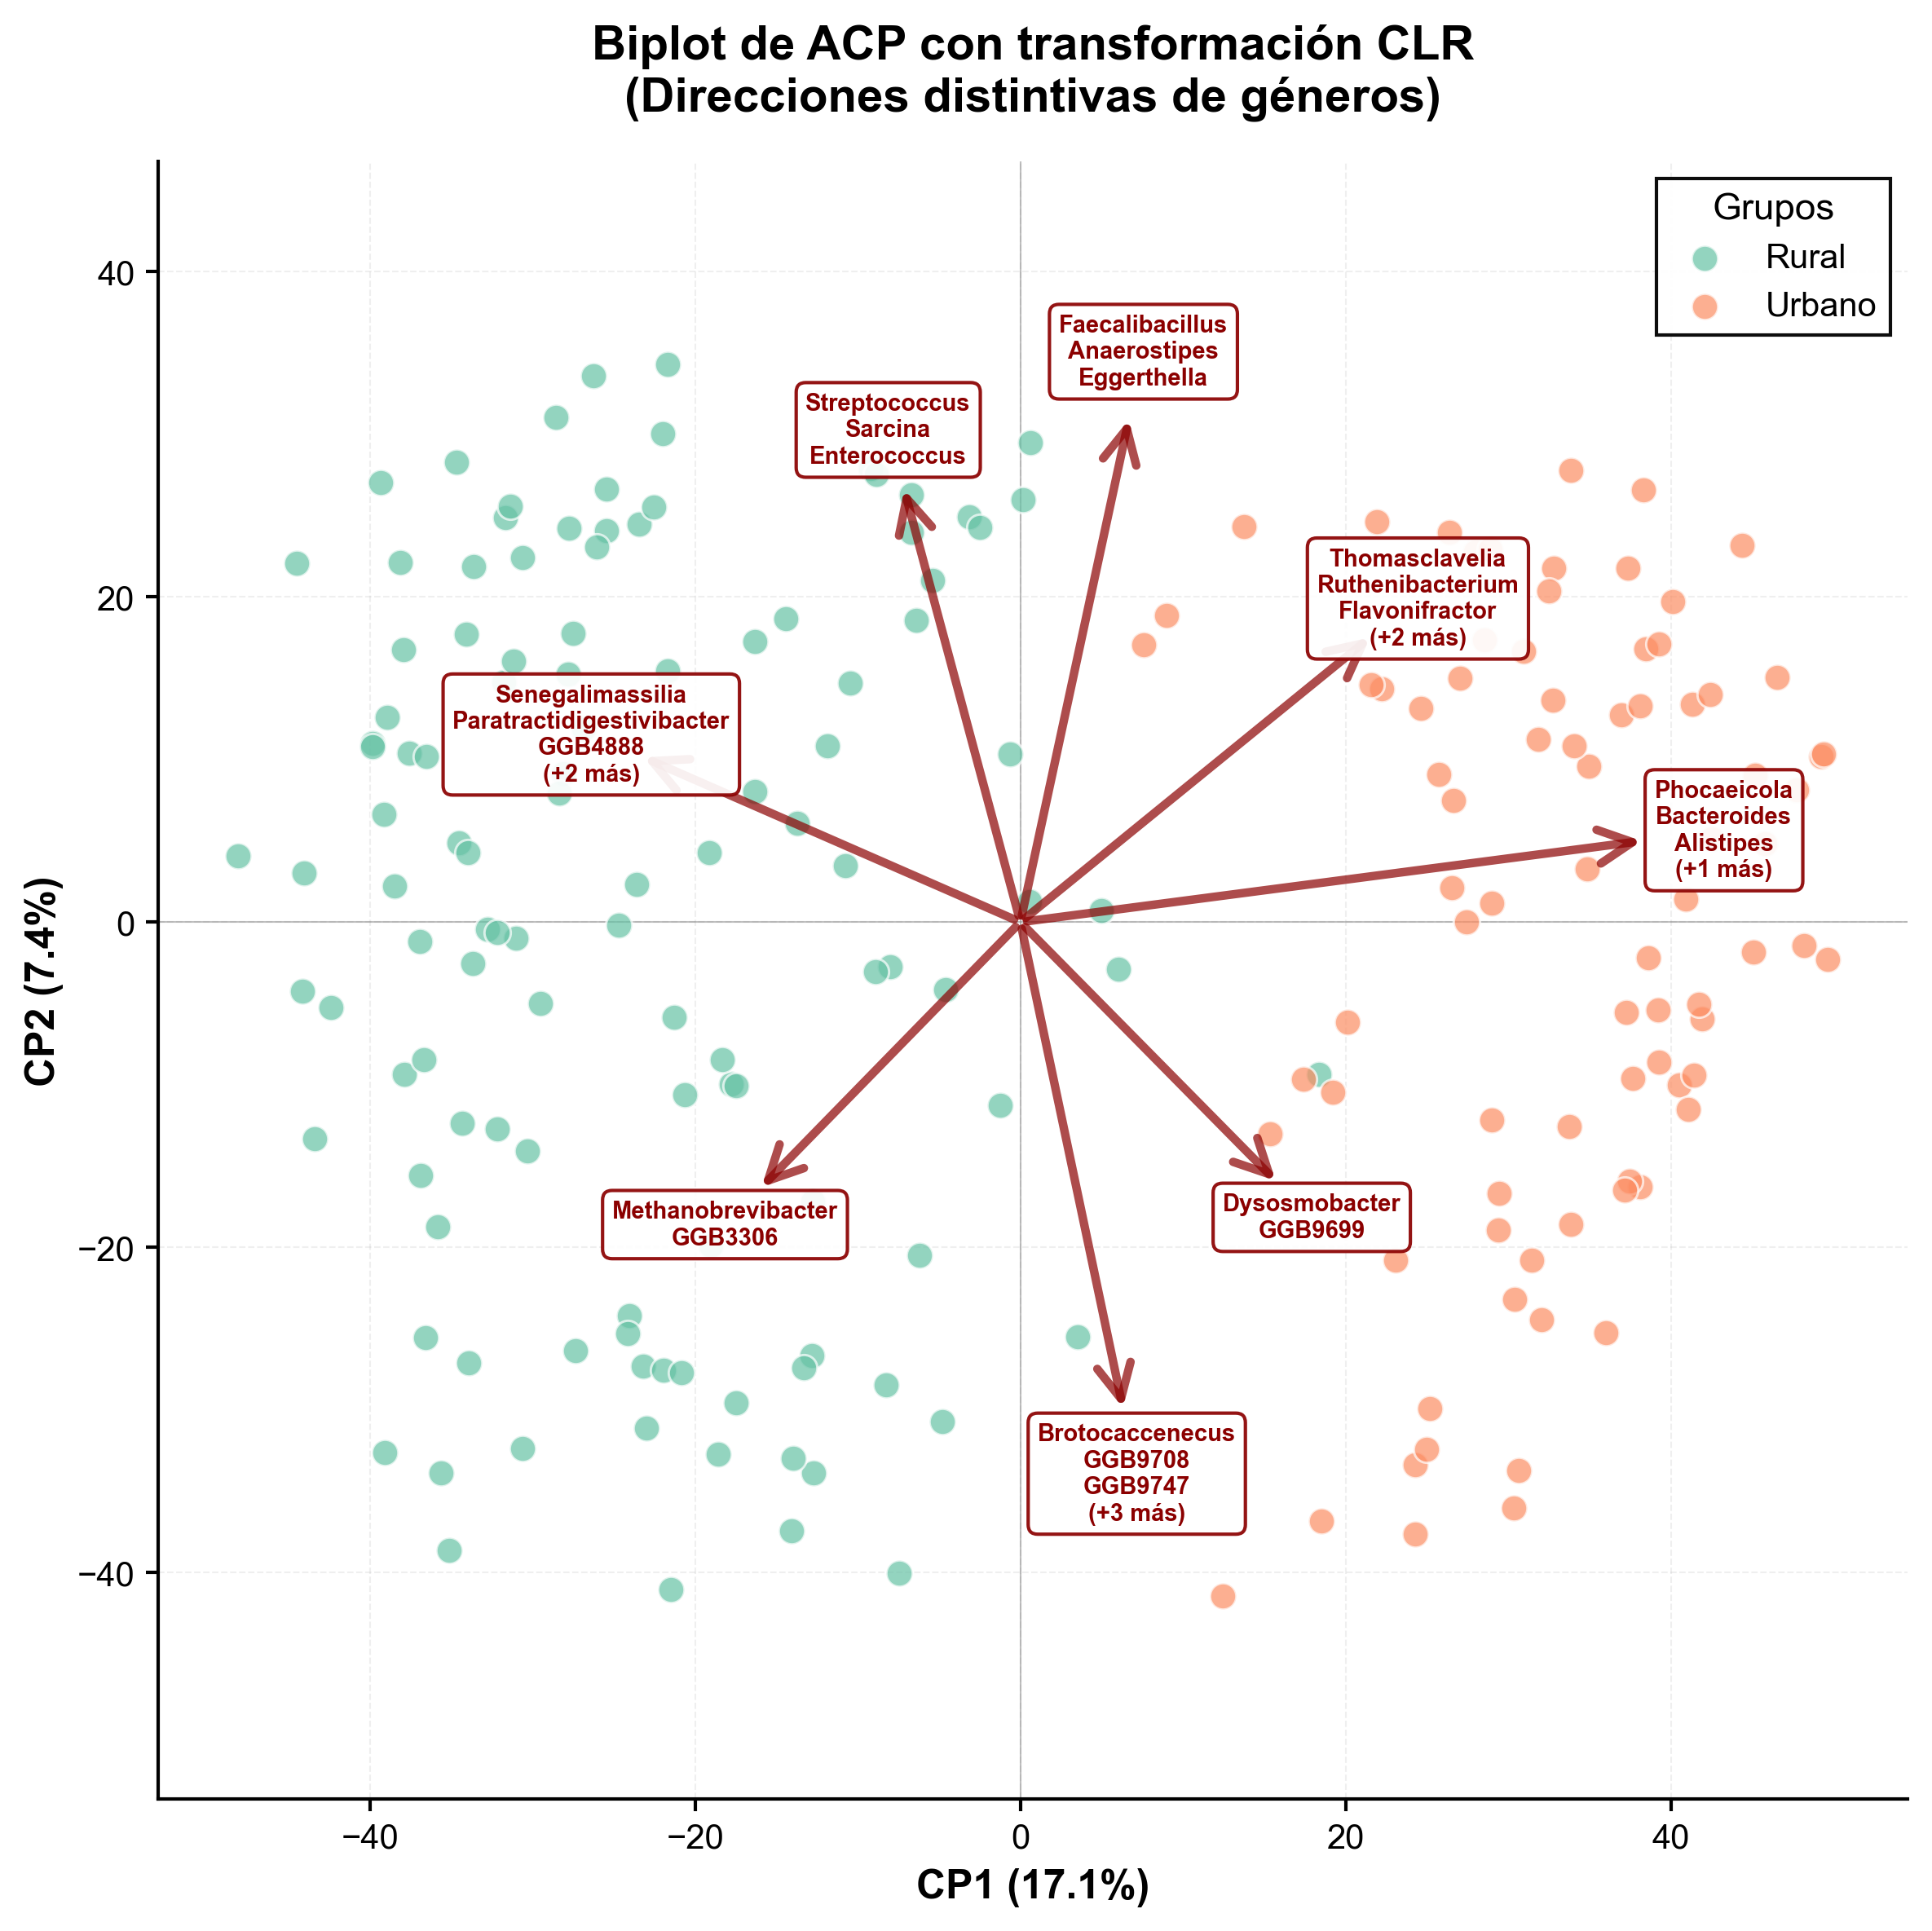

taxonomic_genus: 199 muestras, 439 características
Suma composicional: 100.000000–100.000000
Pseudoconteo: 3.5e-05; PC1+PC2 = 24.5%
Direcciones seleccionadas: 8 de 30 candidatas.


,PC1,PC2,contribution
Phocaeicola,0.193111,0.025222,0.218333
Thomasclavelia,0.109112,0.088829,0.197940
Bacteroides,0.184840,-0.011309,0.196149
Faecalibacillus,0.033769,0.156580,0.190349
GGB3109,0.100621,0.086527,0.187148
Ruthenibacterium,0.136610,0.048085,0.184695
Anaerostipes,0.067101,0.116884,0.183985
GGB9708,0.031944,-0.151397,0.183341
Alistipes,0.176343,-0.006195,0.182538
Eggerthella,0.078783,0.103185,0.181968


In [3]:
# Preparación exclusiva de MetaPhlAn: taxones × muestras → géneros × muestras.
ARROW_LABELS = "names"  # Elegir: "names", "numbers" o "none".

metaphlan = pd.read_csv(DATASETS / "latinbiota_merge_metaphlan_data.csv", sep="\t", skiprows=1, index_col=0)
taxon_names = metaphlan.index.astype(str)
is_genus = (
    taxon_names.str.contains(r"(?:^|\|)g__", regex=True)
    & ~taxon_names.str.contains(r"(?:^|\|)[ts]__", regex=True)
    & ~taxon_names.str.contains("unclassified", case=False)
)
genus = metaphlan.loc[is_genus].copy()
genus.index = [name.split("|g__", 1)[1].split("|", 1)[0].replace("_", " ") for name in genus.index]
genus = genus.groupby(level=0).sum().T

genus_result = run_clr_pca(
    genus, "taxonomic_genus", "Biplot de ACP con transformación CLR\n(Direcciones distintivas de géneros)",
    zero_threshold=180, composition_total=100.0,
    arrow_labels=ARROW_LABELS, arrow_scale=200, figure_size=(8, 8), dpi=300,
)
genus_result["loadings"].head(10)


## 2. Funcional: rutas no estratificadas de HUMAnN


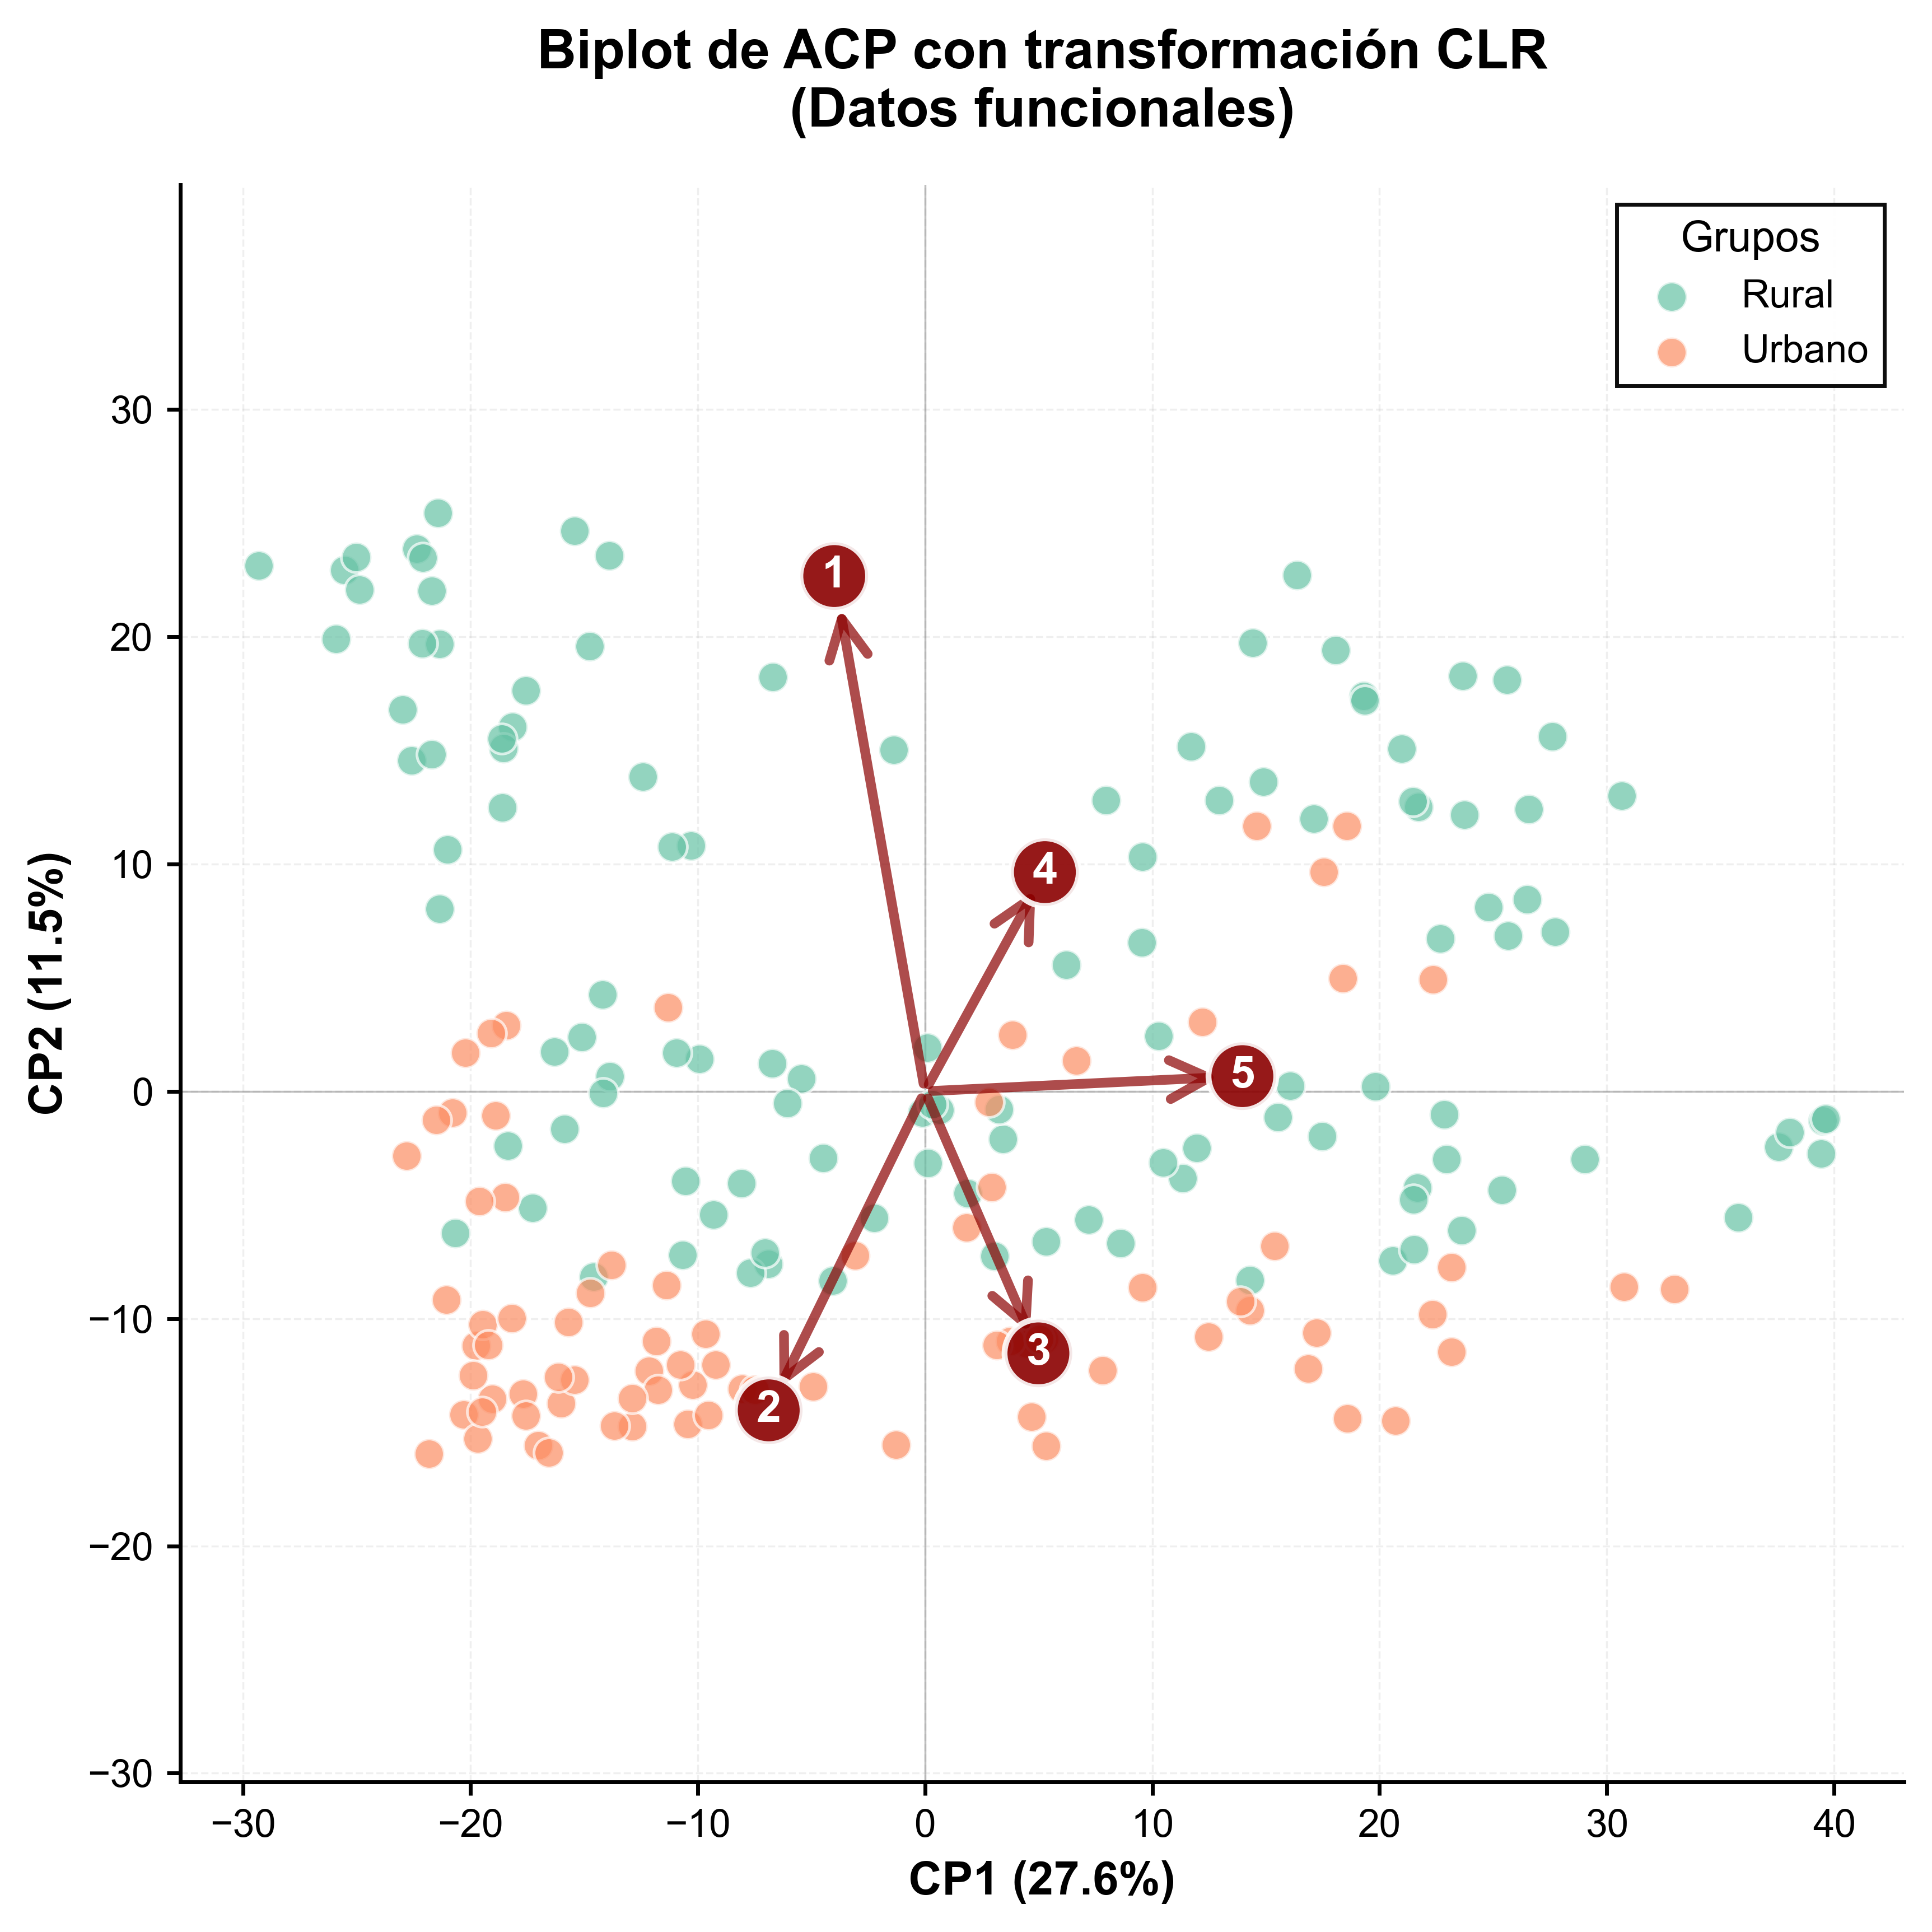

functional_pathways: 199 muestras, 456 características
Suma composicional: 1.000000–1.000000
Pseudoconteo: 9.32165e-08; PC1+PC2 = 39.0%
Direcciones seleccionadas: 5 de 30 candidatas.
Referencias de las flechas:
 reference                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

,PC1,PC2,contribution
# Pathway,,,
PWY-6167: flavin biosynthesis II (archaea),-0.037999,0.215884,0.253883
PWY-6165: chorismate biosynthesis II (archaea),-0.047233,0.206370,0.253603
PWY-5196: factor 430 biosynthesis,-0.040460,0.205041,0.245501
PWY-7286: 7-(3-amino-3-carboxypropyl)-wyosine biosynthesis,-0.041499,0.196162,0.237661
PWY-6654: phosphopantothenate biosynthesis III (archaebacteria),-0.039550,0.195859,0.235409
PWY-5209: methyl-coenzyme M oxidation to CO2,-0.042368,0.192419,0.234788
METHANOGENESIS-PWY: methanogenesis from H2 and CO2,-0.042041,0.192677,0.234718
PWY-5198: factor 420 biosynthesis II (mycobacteria),-0.042368,0.187619,0.229987
PWY-6349: CDP-archaeol biosynthesis,-0.043349,0.186310,0.229658


In [4]:
# Preparación exclusiva de HUMAnN: eliminar filas no asignadas y transponer rutas × muestras.
ARROW_LABELS = "numbers"  # Elegir: "names", "numbers" o "none".

functional = pd.read_csv(DATASETS / "latinbiota_pathabundance_unstratified_relab.tsv", sep="\t", index_col=0)
functional = functional.drop(index=["UNMAPPED", "UNINTEGRATED"], errors="ignore")
functional = functional.loc[:, ~functional.columns.str.contains(r"\.1", regex=True)]
functional = functional.T
functional.index = functional.index.str.replace("_paired_Abundance", "", regex=False)

functional_result = run_clr_pca(
    functional, "functional_pathways", "Biplot de ACP con transformación CLR\n(Datos funcionales)",
    zero_threshold=180, composition_total=1.0,
    arrow_labels=ARROW_LABELS, arrow_scale=100, figure_size=(7, 7), dpi=500,
)
functional_result["loadings"].head(10)


## 3. Datos CAMDA 2026

Análisis adicional del conjunto CAMDA 2026. Replica la preparación de `clr_transformation-Copy1.ipynb`: las especies presentes en más del 90 % de ceros se amalgaman en `otros`, los ceros se sustituyen con la mitad de la menor abundancia positiva y se aplica CLR antes del PCA. Se reutilizan las funciones comunes de esta libreta para la preparación composicional, CLR, PCA, selección de direcciones y biplot.


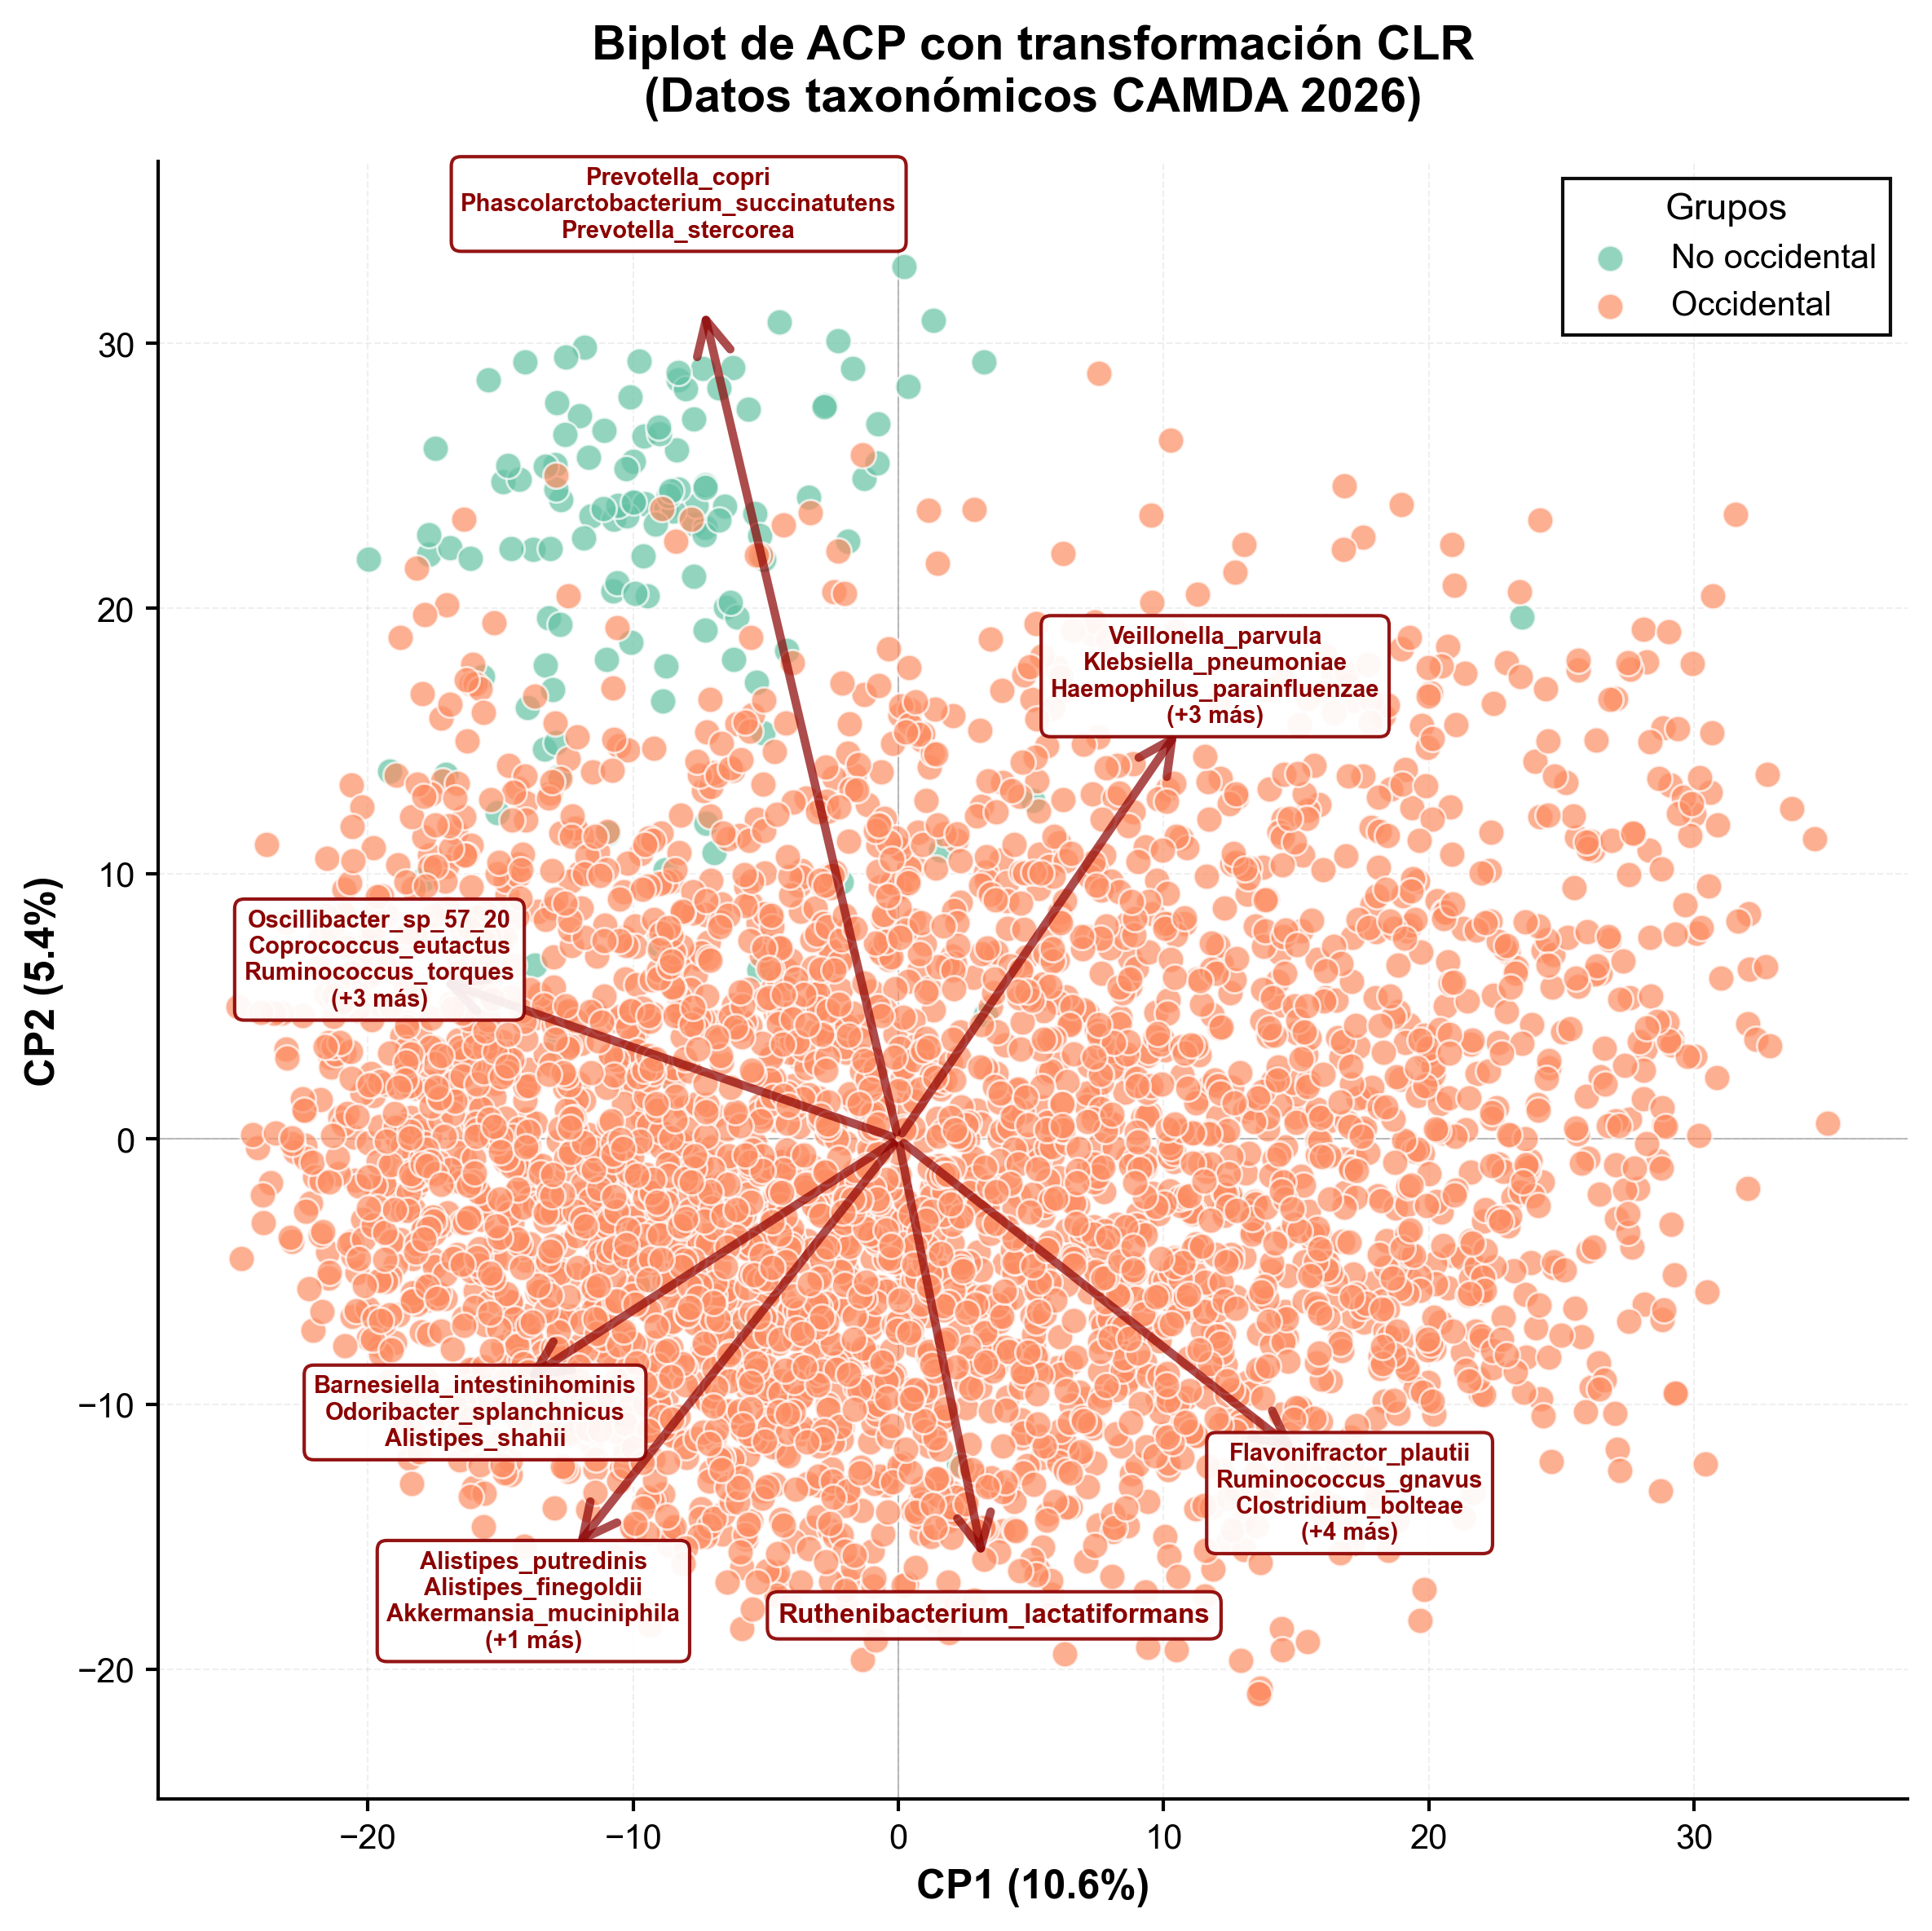

camda_2026_taxonomy: 3752 muestras, 204 características
Suma composicional: 100.000000–100.000988
Pseudoconteo: 0.0005; PC1+PC2 = 16.0%


,PC1,PC2,contribution
Species,,,
Prevotella_copri,-0.073912,0.314721,0.388633
Alistipes_putredinis,-0.122812,-0.155573,0.278385
Flavonifractor_plautii,0.151923,-0.119228,0.271152
Veillonella_parvula,0.106657,0.155766,0.262423
Ruminococcus_gnavus,0.240343,-0.021524,0.261866
Clostridium_bolteae,0.173198,-0.083859,0.257057
Oscillibacter_sp_57_20,-0.174636,0.060351,0.234987
Barnesiella_intestinihominis,-0.142458,-0.092089,0.234547
Alistipes_finegoldii,-0.079462,-0.154307,0.233769


In [5]:
# CAMDA 2026: abundancia taxonómica relativa y metadatos por muestra.
CAMDA_DATA = EXTERNAL_DATA
CAMDA_TAXONOMY = CAMDA_DATA / "camda_2026_taxonomy_relative_abundance.tsv"
CAMDA_METADATA = CAMDA_DATA / "camda_2026_metadata.tsv"
CAMDA_NAME = "camda_2026_taxonomy"

# La tabla de origen tiene taxones en filas; el PCA requiere muestras en filas.
camda_taxonomy = pd.read_csv(CAMDA_TAXONOMY, sep="\t", index_col=0).T
camda_metadata = pd.read_csv(CAMDA_METADATA, sep="\t").drop_duplicates("sample_id")
camda_metadata = camda_metadata.set_index("sample_id")

# Se conserva la agrupación de la libreta original: occidentalizada / no occidentalizada.
camda_groups = camda_metadata["non_westernized"].reindex(camda_taxonomy.index)
valid_camda_samples = camda_groups.isin(["yes", "no"])
camda_taxonomy = camda_taxonomy.loc[valid_camda_samples].apply(pd.to_numeric, errors="coerce").fillna(0)
camda_groups = camda_groups.loc[valid_camda_samples].map({"yes": "No occidental", "no": "Occidental"})

# Preparación composicional equivalente al experimento CAMDA original.
camda_minimum_positive = camda_taxonomy.where(camda_taxonomy > 0).min().min()
if pd.isna(camda_minimum_positive):
    raise ValueError("CAMDA 2026: no hay abundancias positivas.")
camda_pseudocount = camda_minimum_positive / 2
camda_zero_threshold = int(0.9 * len(camda_taxonomy))
camda_composition = amalgamate_sparse_features(
    camda_taxonomy, zero_threshold=camda_zero_threshold, composition_total=100.0, other_name="otros"
)
camda_composition = replace_zeros_preserving_total(camda_composition, camda_pseudocount)

# Misma salvaguarda del experimento fuente para el residual de la categoría `otros`.
tiny_negative_other = (camda_composition["otros"] < 0) & (camda_composition["otros"] > -camda_pseudocount)
camda_composition.loc[tiny_negative_other, "otros"] = camda_pseudocount
if (camda_composition <= 0).any().any():
    raise ValueError("CAMDA 2026: quedaron valores no positivos tras el tratamiento de ceros.")

camda_clr = apply_clr(camda_composition)
camda_pca, camda_scores, camda_loadings = fit_pca(camda_clr)
camda_directions = select_distinct_directions(camda_loadings, top_candidates=30, distance_threshold=0.1)
camda_figure, camda_references = plot_pca_biplot(
    camda_scores, camda_groups, camda_directions, camda_pca,
    "Biplot de ACP con transformación CLR\n(Datos taxonómicos CAMDA 2026)",
    arrow_labels="names", arrow_scale=100, figure_size=(8, 8), dpi=300,
)

# Productos reproducibles del experimento adicional.
camda_scores.assign(Westernization=camda_groups).to_csv(TABLES / f"{CAMDA_NAME}_pca_scores.csv")
camda_loadings.to_csv(TABLES / f"{CAMDA_NAME}_pca_loadings.csv")
camda_references.to_csv(TABLES / f"{CAMDA_NAME}_arrow_references.csv", index=False)
camda_figure.savefig(FIGURES / f"{CAMDA_NAME}_clr_pca_biplot.png", dpi=300, bbox_inches="tight")
camda_figure.savefig(FIGURES / f"{CAMDA_NAME}_clr_pca_biplot.pdf", bbox_inches="tight")
plt.show()

print(f"{CAMDA_NAME}: {len(camda_composition)} muestras, {camda_composition.shape[1]} características")
print(f"Suma composicional: {camda_composition.sum(axis=1).min():.6f}–{camda_composition.sum(axis=1).max():.6f}")
print(f"Pseudoconteo: {camda_pseudocount:g}; PC1+PC2 = {camda_pca.explained_variance_ratio_[:2].sum():.1%}")
camda_loadings.head(10)
